In [1]:
from sklearn import datasets
import numpy as np
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Random Classification Data with 2 classes')

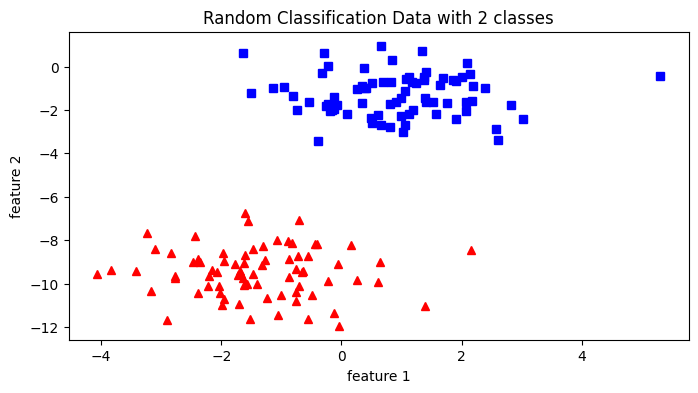

In [8]:
X, y = datasets.make_blobs (n_samples=150, n_features=2,
 centers=2, cluster_std=1.05,
random_state=2)
#Plotting
fig = plt.figure(figsize=(8,4))
plt.plot(X[:, 0][y == 0], X[:, 1][y == 0], 'r^')
plt.plot(X[:, 0][y == 1], X[:, 1][y == 1], 'bs')
plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.title('Random Classification Data with 2 classes')

**Choisir la fonction d'activation**

In [10]:
def acti_func(z):
  if z > 0:
        return 1
  else:
        return 0

**Defining the perceptron algorithm**

In [11]:
def perceptron(X, y, lr, epochs):
    # m: nombre d'exemples, n: nombre de features
    m, n = X.shape

    # Initialisation des poids (n+1 pour inclure le biais w0)
    w = np.zeros((n + 1, 1))
    n_miss_list = []

    for epoch in range(epochs):
        n_miss = 0
        for idx, x_i in enumerate(X):
            # Insertion de 1 pour le biais (X0 = 1)
            x_i = np.insert(x_i, 0, 1).reshape(-1, 1)

            # Calcul de la prédiction (Hypothèse)
            y_hat = acti_func(np.dot(x_i.T, w))

            # Mise à jour des poids si l'exemple est mal classé
            # Règle du Perceptron : w = w + lr * (y - y_hat) * x
            error = y[idx] - y_hat
            if error != 0:
                w += lr * error * x_i
                n_miss += 1

        n_miss_list.append(n_miss)

    return w, n_miss_list



In [12]:
def plot_decision_boundary(X, y, w):
    """
    Trace la limite de décision.
    L'équation est : w0 + w1*x1 + w2*x2 = 0
    D'où : x2 = -(w1/w2)*x1 - (w0/w2)
    """
    # Points pour la ligne
    x1 = np.array([min(X[:, 0]), max(X[:, 0])])

    # Calcul de la pente (m) et de l'ordonnée à l'origine (c)
    m = -w[1] / w[2]
    c = -w[0] / w[2]

    x2 = m * x1 + c

    # Affichage
    plt.figure(figsize=(10, 6))
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter')
    plt.plot(x1, x2, color='red', label='Frontière de décision')
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.show()

In [22]:
# Entraînement (exemple)
w, errors = perceptron(X, y, lr=0.1, epochs=10)

print("Matrice des poids complète :")
print(w)

Matrice des poids complète :
[[1.        ]
 [0.14885954]
 [0.16938433]]


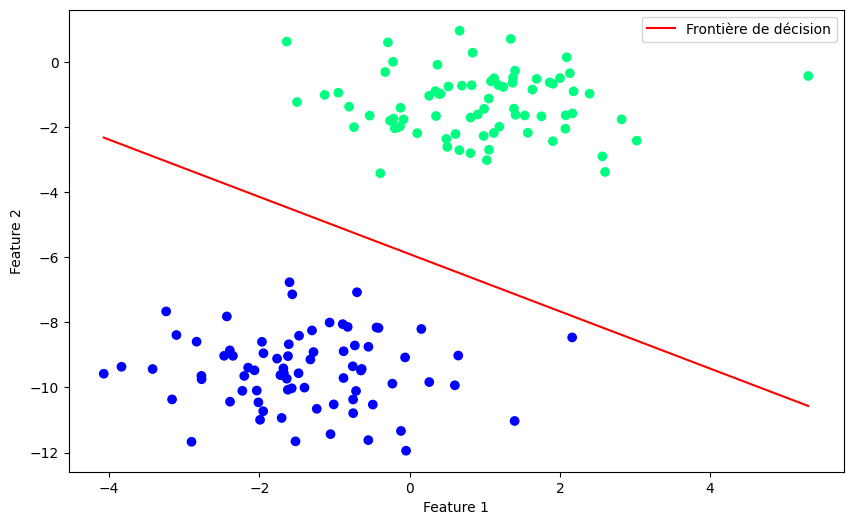

In [ ]:
plot_decision_boundary(X,y,w)